In [ ]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn"])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

In [ ]:
df = pd.read_csv('kagglev2-may-2016.csv')
print("Dataset loaded!")
print("Shape:", df.shape)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [13]:
print(df['No-show'].value_counts())
print("\nNo-show rate:", round(df['No-show'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

No-show
No     88207
Yes    22319
Name: count, dtype: int64

No-show rate: 20.19 %


In [22]:
# ---- DATA QUALITY INVESTIGATION: Negative Waiting Days ----

# Load fresh copy just for investigation
df_invest = pd.read_csv('kagglev2-may-2016.csv')
df_invest['ScheduledDay'] = pd.to_datetime(df_invest['ScheduledDay'])
df_invest['AppointmentDay'] = pd.to_datetime(df_invest['AppointmentDay'])
df_invest['DaysWaiting'] = (df_invest['AppointmentDay'] - df_invest['ScheduledDay']).dt.days

# Step 1 - How many negative waiting days exist?
negative = df_invest[df_invest['DaysWaiting'] < 0]
print("Total rows with negative waiting days:", len(negative))

# Step 2 - Distribution analysis
print("\nDays waiting distribution for negative values:")
print(negative['DaysWaiting'].describe())

# Step 3 - Breakdown by value
print("\nBreakdown of negative waiting days:")
print(df_invest[df_invest['DaysWaiting'] < 0]['DaysWaiting'].value_counts().sort_index())

print("""
FINDINGS:
- 38,563 records have DaysWaiting = -1 → mean is almost exactly -1, std is near 0
- This strongly suggests a timezone/system artifact (same day appointments recorded as -1)
- Decision: Set -1 to 0 (treat as same day appointment, keep the record)
- Only 5 records have DaysWaiting < -1 (-2 and -7)
- These cannot be explained by timezone differences
- Decision: Remove these 5 records as corrupt data
""")

Total rows with negative waiting days: 38568

Days waiting distribution for negative values:
count    38568.000000
mean        -1.000259
std          0.032204
min         -7.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max         -1.000000
Name: DaysWaiting, dtype: float64

Breakdown of negative waiting days:
DaysWaiting
-7        1
-2        4
-1    38563
Name: count, dtype: int64

FINDINGS:
- 38,563 records have DaysWaiting = -1 → mean is almost exactly -1, std is near 0
- This strongly suggests a timezone/system artifact (same day appointments recorded as -1)
- Decision: Set -1 to 0 (treat as same day appointment, keep the record)
- Only 5 records have DaysWaiting < -1 (-2 and -7)
- These cannot be explained by timezone differences
- Decision: Remove these 5 records as corrupt data



In [23]:
# ---- DATA CLEANING ----

df = pd.read_csv('kagglev2-may-2016.csv')

# Remove invalid age rows
df = df[df['Age'] >= 0]

# Convert dates
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Create DaysWaiting column
df['DaysWaiting'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Remove 5 corrupt records (DaysWaiting < -1)
corrupt = len(df[df['DaysWaiting'] < -1])
print(f"Removing {corrupt} corrupt records (DaysWaiting < -1)")
df = df[df['DaysWaiting'] >= -1]

# Set -1 to 0 (timezone artifact - same day appointments)
df['DaysWaiting'] = df['DaysWaiting'].clip(lower=0)

print("Data cleaned!")
print("New shape:", df.shape)
print("Rows with DaysWaiting = 0:", len(df[df['DaysWaiting'] == 0]))


Removing 5 corrupt records (DaysWaiting < -1)
Data cleaned!
New shape: (110521, 15)
Rows with DaysWaiting = 0: 43775


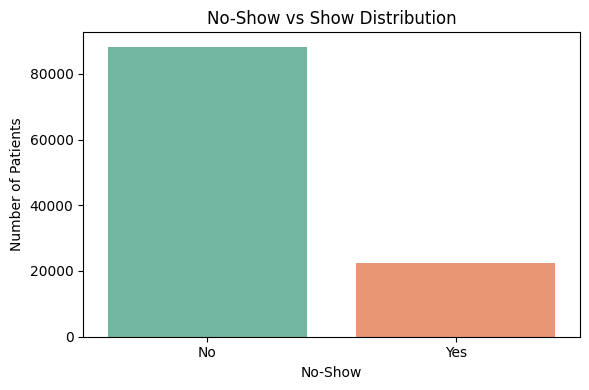

Chart saved!


In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='No-show', hue='No-show', palette='Set2', legend=False)
plt.title('No-Show vs Show Distribution')
plt.xlabel('No-Show')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('01_noshow_distribution.png')
plt.show()
print("Chart saved!")

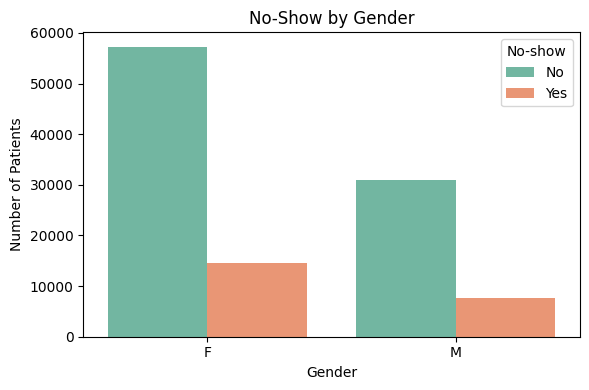

Chart saved!


In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', hue='No-show', palette='Set2')
plt.title('No-Show by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('02_noshow_by_gender.png')
plt.show()
print("Chart saved!")

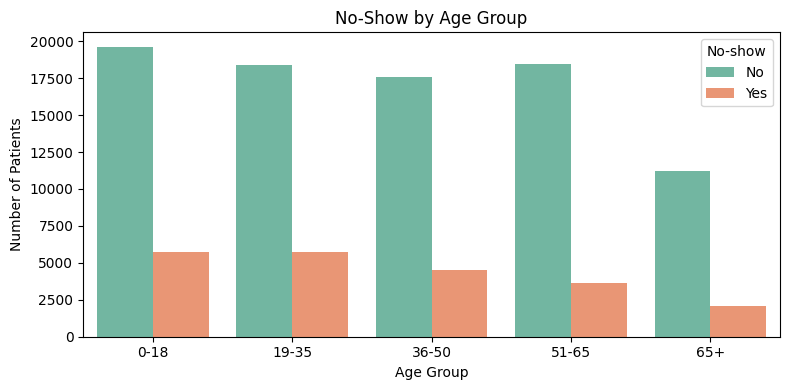

Chart saved!


In [26]:
# Create age groups
bins = [0, 18, 35, 50, 65, 115]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='AgeGroup', hue='No-show', palette='Set2')
plt.title('No-Show by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('03_noshow_by_age.png')
plt.show()
print("Chart saved!")

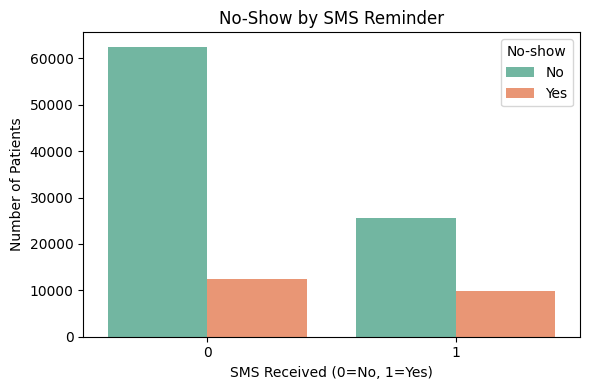

Chart saved!


In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SMS_received', hue='No-show', palette='Set2')
plt.title('No-Show by SMS Reminder')
plt.xlabel('SMS Received (0=No, 1=Yes)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('04_noshow_by_sms.png')
plt.show()
print("Chart saved!")

In [30]:
# No-show RATE by SMS (percentage is more meaningful than raw counts)
print("No-show RATE by SMS:")
sms_rate = df.groupby('SMS_received')['No-show'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
print(sms_rate)

print("\nNo-show RATE by Gender:")
gender_rate = df.groupby('Gender')['No-show'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
print(gender_rate)

print("\nNo-show RATE by Age Group:")
age_rate = df.groupby('AgeGroup',observed=True)['No-show'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
print(age_rate)

No-show RATE by SMS:
SMS_received
0    16.70
1    27.57
Name: No-show, dtype: float64

No-show RATE by Gender:
Gender
F    20.31
M    19.96
Name: No-show, dtype: float64

No-show RATE by Age Group:
AgeGroup
0-18     22.53
19-35    23.83
36-50    20.32
51-65    16.55
65+      15.53
Name: No-show, dtype: float64


Average waiting days:
No-show
No      8.2
Yes    14.9
Name: DaysWaiting, dtype: float64

No-show RATE by Waiting Time:
WaitingGroup
Same Day       8.92
1-7 days      25.36
8-30 days     32.00
31-60 days    34.08
60+ days      28.83
Name: No-show, dtype: float64
No-show RATE by Granular Waiting Time:
WaitingGroup2
Same Day       8.92
1-7 days      25.36
8-14 days     31.23
15-21 days    32.34
22-30 days    32.72
31-60 days    34.08
60+ days      28.83
Name: No-show, dtype: float64


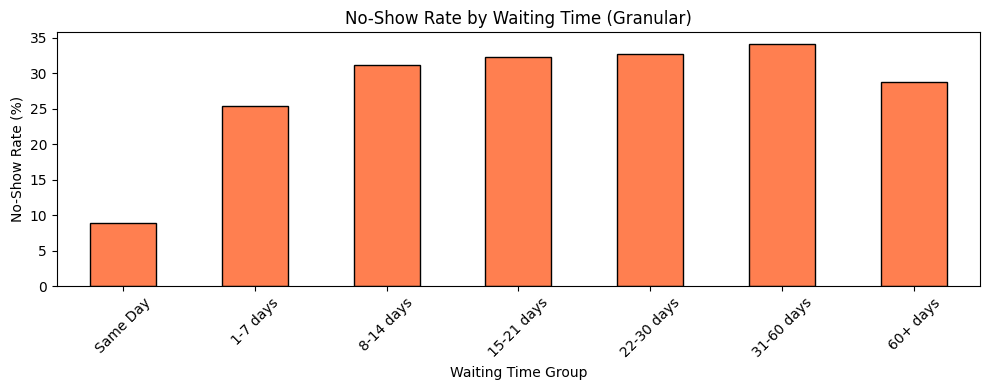

Chart saved!


In [33]:
# Average waiting days for show vs no-show
print("Average waiting days:")
print(df.groupby('No-show')['DaysWaiting'].mean().round(1))

# No-show rate by waiting time buckets
bins = [0, 1, 7, 30, 60, 300]
labels = ['Same Day', '1-7 days', '8-30 days', '31-60 days', '60+ days']
df['WaitingGroup'] = pd.cut(df['DaysWaiting'], bins=bins, labels=labels, include_lowest=True)

wait_rate = df.groupby('WaitingGroup', observed=True)['No-show'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
print("\nNo-show RATE by Waiting Time:")
print(wait_rate)

# More granular waiting time analysis
bins2 = [0, 1, 7, 14, 21, 30, 60, 300]
labels2 = ['Same Day', '1-7 days', '8-14 days', '15-21 days', '22-30 days', '31-60 days', '60+ days']
df['WaitingGroup2'] = pd.cut(df['DaysWaiting'], bins=bins2, labels=labels2, include_lowest=True)

wait_rate2 = df.groupby('WaitingGroup2', observed=True)['No-show'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
print("No-show RATE by Granular Waiting Time:")
print(wait_rate2)

plt.figure(figsize=(10,4))
wait_rate2.plot(kind='bar', color='coral', edgecolor='black')
plt.title('No-Show Rate by Waiting Time (Granular)')
plt.xlabel('Waiting Time Group')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('05_noshow_by_waiting_granular.png')
plt.show()
print("Chart saved!")

In [34]:
# ---- BUSINESS RECOMMENDATIONS ----

recommendations = """
HEALTHCARE APPOINTMENT NO-SHOW ANALYSIS
Business Recommendations
========================================

DATASET: 110,521 patient appointments from Brazilian clinics
OVERALL NO-SHOW RATE: 20.2% (1 in 5 patients do not show up)

KEY FINDINGS:
=============

1. WAITING TIME IS THE STRONGEST PREDICTOR OF NO-SHOWS
   - Same day appointments have only 8.92% no-show rate
   - No-show rate jumps dramatically to 25.36% for 1-7 day wait
   - Highest risk window is 31-60 days (34.08% no-show rate)
   - Patients who book 60+ days ahead are more committed (28.83%)

2. SMS REMINDERS NEED BETTER TARGETING STRATEGY
   - Counter-intuitively, patients who received SMS had higher no-show rates
   - Likely because SMS was sent to already high-risk patients
   - Current SMS strategy is reactive, not preventive

3. YOUNGER PATIENTS (19-35) ARE HIGHEST RISK AGE GROUP
   - Likely due to busy work schedules and lower health urgency
   - 0-18 age group also high risk (dependent on parents)
   - Patients aged 51+ have significantly better attendance

4. GENDER HAS NO MEANINGFUL IMPACT (0.35% difference)
   - Not a useful factor for targeting interventions

RECOMMENDATIONS:
================

1. SAME-DAY WAITLIST SYSTEM
   - Maintain a waitlist of patients for same-day cancellation slots
   - Same-day patients have only 8.92% no-show rate
   - This could significantly reduce empty appointment slots

2. TARGETED SMS REMINDERS FOR HIGH-RISK WINDOW
   - Focus SMS reminders on patients in the 15-60 day waiting window
   - These patients have 32-34% no-show rate
   - Send reminders at 7 days and 24 hours before appointment
   - Consider phone calls for 31-60 day appointments

3. OVERBOOKING STRATEGY FOR HIGH-RISK SLOTS
   - For appointments in 15-60 day window, consider slight overbooking
   - Similar to airline overbooking strategy
   - Reduces revenue loss from empty slots

4. TARGETED INTERVENTIONS FOR YOUNG PATIENTS (19-35)
   - Offer flexible rescheduling options via mobile app
   - Send appointment reminders via preferred channels (WhatsApp, SMS)
   - Allow easy online cancellation to free up slots for others

5. REVIEW SMS REMINDER TARGETING CRITERIA
   - Analyse which patient segments are currently receiving SMS
   - Redirect SMS budget to genuinely high-risk patients
   - Track SMS effectiveness per patient segment separately
"""

print(recommendations)


HEALTHCARE APPOINTMENT NO-SHOW ANALYSIS
Business Recommendations

DATASET: 110,521 patient appointments from Brazilian clinics
OVERALL NO-SHOW RATE: 20.2% (1 in 5 patients do not show up)

KEY FINDINGS:

1. WAITING TIME IS THE STRONGEST PREDICTOR OF NO-SHOWS
   - Same day appointments have only 8.92% no-show rate
   - No-show rate jumps dramatically to 25.36% for 1-7 day wait
   - Highest risk window is 31-60 days (34.08% no-show rate)
   - Patients who book 60+ days ahead are more committed (28.83%)

2. SMS REMINDERS NEED BETTER TARGETING STRATEGY
   - Counter-intuitively, patients who received SMS had higher no-show rates
   - Likely because SMS was sent to already high-risk patients
   - Current SMS strategy is reactive, not preventive

3. YOUNGER PATIENTS (19-35) ARE HIGHEST RISK AGE GROUP
   - Likely due to busy work schedules and lower health urgency
   - 0-18 age group also high risk (dependent on parents)
   - Patients aged 51+ have significantly better attendance

4. GENDER H

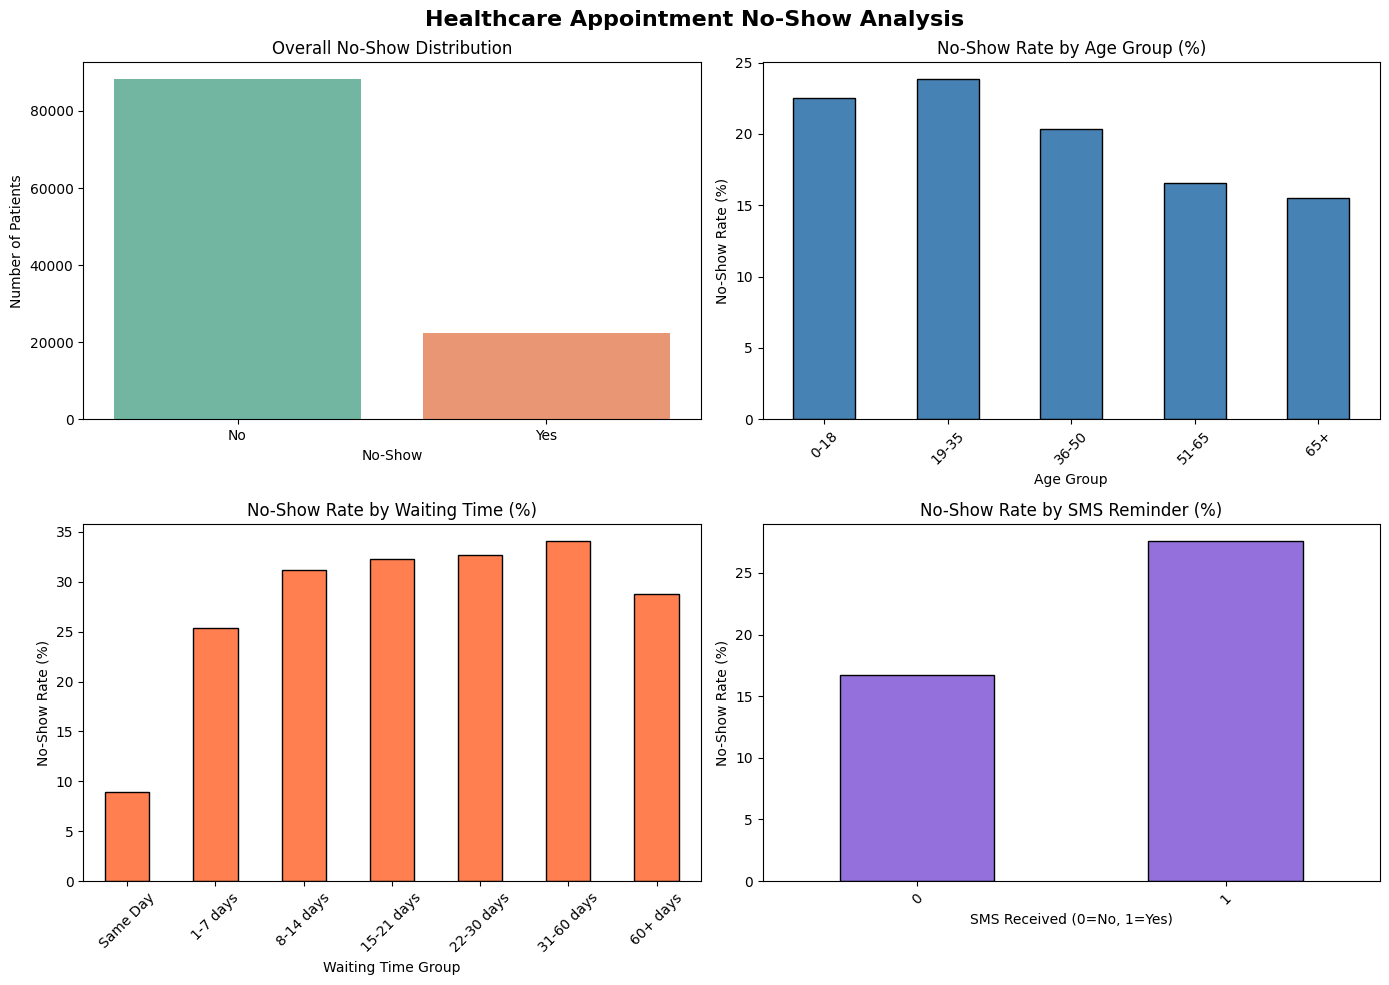

Summary dashboard saved!


In [35]:
# ---- SUMMARY DASHBOARD ----

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Healthcare Appointment No-Show Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Overall No-Show Distribution
sns.countplot(data=df, x='No-show', hue='No-show', palette='Set2', legend=False, ax=axes[0,0])
axes[0,0].set_title('Overall No-Show Distribution')
axes[0,0].set_xlabel('No-Show')
axes[0,0].set_ylabel('Number of Patients')

# Chart 2 - No-Show Rate by Age Group
age_rate.plot(kind='bar', color='steelblue', edgecolor='black', ax=axes[0,1])
axes[0,1].set_title('No-Show Rate by Age Group (%)')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('No-Show Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - No-Show Rate by Waiting Time
wait_rate2.plot(kind='bar', color='coral', edgecolor='black', ax=axes[1,0])
axes[1,0].set_title('No-Show Rate by Waiting Time (%)')
axes[1,0].set_xlabel('Waiting Time Group')
axes[1,0].set_ylabel('No-Show Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4 - No-Show Rate by SMS
sms_rate.plot(kind='bar', color='mediumpurple', edgecolor='black', ax=axes[1,1])
axes[1,1].set_title('No-Show Rate by SMS Reminder (%)')
axes[1,1].set_xlabel('SMS Received (0=No, 1=Yes)')
axes[1,1].set_ylabel('No-Show Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('06_summary_dashboard.png', dpi=150)
plt.show()
print("Summary dashboard saved!")